# TME Composition ISP Analysis Tutorial

This tutorial demonstrates how to analyze In Silico Perturbation (ISP) results for **TME (Tumor Microenvironment) composition** experiments. Unlike target-rank perturbations, TME composition ISP simulates changing the proportions of different cell types within the tumor microenvironment to study their effects on cell state transitions.

## Overview

In this tutorial, you will learn how to:
1. Run TME composition ISP simulations
2. Load and analyze TME composition ISP results
3. Visualize the effects of different TME cell type expansions on cell state transitions

## TME Cell Types

The Xenium dataset contains the following TME cell types:

| tme_id | Cell Type |
|--------|-----------|
| 1 | Epithelia |
| 2 | T_lymph |
| 3 | Monocyte |
| 5 | Fibroblast |
| 6 | Endothelial |
| 7 | B_lymph |
| 8 | Mast |

## Prerequisites

Before running this notebook, you need to:
- Have the `TMEformer` package installed
- Run the TME composition ISP simulation script (see below)

### Step 0: Run TME Composition ISP Simulation

First, execute the TME composition ISP simulation script to generate perturbation results:

```bash
# TME Composition ISP for cluster 2 (T_lymph)
tmeformer-emb-isp-tme --device 1 \
--proj xenium --task ADT2CRPC \
--direction 'ADT>CRPC' \
--tme_method composition \
--model_ids GF_D1120_06 \
--isp_cluster 2 --cell_cluster_file main \
--endpoints 2 --window 0.1 \
--cell_ratio 1000
```


Repeat the command with different `--isp_cluster` values (2, 3, 5, 6, 7, 8) to perturb different TME cell types.

## Step 1: Setup and Data Loading

Import required libraries, configure the working directory, and load metadata.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import TMEformer.tme.TmeModeling_utils_isp_sim as tu_isp_sim
import TMEformer.tme.TmeModeling_utils as tu

/home/liss/miniconda3/envs/geneformer_v3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set the base working directory
work_dir = "/dataSSD7T/liss/work/scPCa/model_paper/TMEformer-analysis/"
assert os.path.exists(work_dir), f"Working directory not found: {work_dir}"

In [3]:
# Load cell metadata
obsmeta = pd.read_csv(work_dir + "data/xenium/processed/xenium_obsmeta.csv")
obsmeta = obsmeta.rename(columns={"patch_2000": "patch_id"})

# Create TME ID to cell type mapping
celltype_dict = obsmeta[["tme_id", "cell_type"]].drop_duplicates().set_index("tme_id").sort_index()["cell_type"].to_dict()
print("TME ID to Cell Type Mapping:", celltype_dict)


TME ID to Cell Type Mapping: {1: 'Epithelia', 2: 'T_lymph', 3: 'Monocyte', 5: 'Fibroblast', 6: 'Endothelial', 7: 'B_lymph', 8: 'Mast'}


In [4]:

# Optional: Recompute patch IDs with smaller patch size for higher resolution
patch_size = 500
obsmeta = obsmeta.groupby("sample_id", group_keys=False).apply(
    tu.compute_patch_ids,
    patch_size=patch_size,
    include_groups=False
)

## Step 2: Load and Process ISP Results

Configure the analysis task, load ISP simulation results, and filter for the desired conditions.

In [5]:
# Configure analysis parameters
task = "ADT2CRPC"
task_dir = work_dir + f"isp_emb_sim/task_{task}"
isp_type = "tme_composition"


In [6]:

# Define TME composition conditions to analyze
conditions_dict = {
    "Target": [
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME2_FIXall",  
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME3_FIXall",  
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME5_FIXall",  
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME6_FIXall",  
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME7_FIXall",   
        "ADT2CRPC_ADT>CRPC-TME_Composition-L1-S1000-W0.2_EP2.0_KO0_KI0-TME8_FIXall"   
    ]
}

# Select model
model_ids = ["GF_D1120_06"]

In [7]:
# Merge ISP results for TME composition
stats_raw = tu_isp_sim.merge_isp_sim_stat_raw(
    conditions_dict, task, model_ids,
    tme_isp=True, tme_method="composition", work_dir=work_dir
)

# Map TME IDs to cell type names
stats_raw["cell_type"] = stats_raw["cell_type"].apply(lambda x: celltype_dict.get(x, x))
stats_raw["group"] = stats_raw["group"].apply(lambda x: celltype_dict.get(x, x))

# Merge with metadata to get patch information
stats_raw = pd.merge(stats_raw, obsmeta[["cell_id", "patch_id"]])


In [8]:

# Filter and aggregate results at patch level
stats_filt = tu_isp_sim.filter_isp_sim_stat_raw(
    stats_raw, score_type="OE", score_method="endpoint",
    stat_level="patch", stat_method="mean", pair=True,
)

print(f"Loaded {len(stats_filt)} records")
print(f"TME cell types: {stats_filt['group'].unique()}")

Loaded 1517 records
TME cell types: ['Endothelial' 'Fibroblast' 'Mast' 'Monocyte' 'T_lymph' 'B_lymph']


## Step 3: Visualization and Interpretation

Create a bar plot showing the effect of expanding different TME cell types on the ADT to CRPC transition.

In [9]:
# Filter for specific model and prepare data
model_id = "GF_D1120_06"
stats_filt2 = stats_filt[stats_filt["model_id"] == model_id]
all_tme_types = stats_filt2["group"].unique().tolist()

# Configure plot parameters
plot_params = {
    "x": "group",
    "order": sorted(all_tme_types),
    "hue": "group",
    "width": 0.6,
    "errcolor": "#333333",
    "errwidth": 1,
    "linewidth": 0.4,
    "edgecolor": "black",
    "saturation": 1
}


/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:416: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': '#333333'}` instead.

  ax = sns.barplot(data=stats_filt, y="cell_score", **kwargs)
/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:416: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  ax = sns.barplot(data=stats_filt, y="cell_score", **kwargs)
/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:541: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=None)
/dataSSD7T/liss/work/scPCa/model/TMEformer-repo/TMEformer/tme/TmeModeling_utils_isp_sim.py:544: UserWarning: No artists with lab

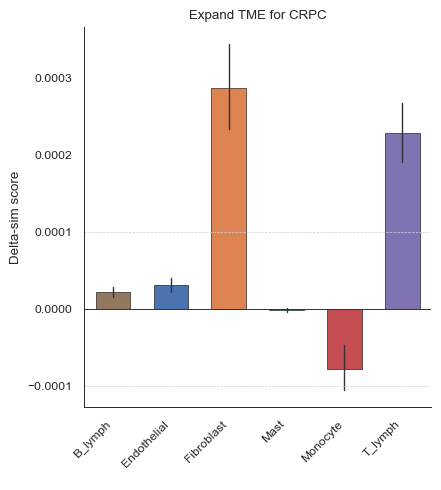

In [10]:

# Create the visualization
sns.set_theme(context='paper', style='white')

ax = tu_isp_sim.vis_delta_emb_sim_boxbar(
    stats_filt2,
    title_text="Expand TME for CRPC",
    xlabel_text=None,
    ylabel_text="Delta-sim score",
    figsize=(4.5, 5),
    wilcoxon_test=None,
    geom_type="bar",
    **plot_params
)

# Add reference lines
plt.axhline(0, color='#333333', linewidth=0.7, linestyle='-')
plt.axhline(0.0001, color='lightgrey', linewidth=0.5, linestyle='--')
plt.axhline(-0.0001, color='lightgrey', linewidth=0.5, linestyle='--')

# Style the plot
sns.despine()
ax = plt.gca()
ax.spines['left'].set_linewidth(0.7)
ax.spines['bottom'].set_linewidth(0.7)

plt.tight_layout()
plt.show()

## Interpretation

The plot shows the delta similarity scores for expanding different TME cell types:

- **Positive scores**: Expanding this cell type drives cells towards the CRPC state
- **Negative scores**: Expanding this cell type drives cells away from the CRPC state